In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install polars

In [3]:
import numpy as np
import pandas as pd

import pyarrow.parquet as pq
import polars as pl

from scipy import stats

from pathlib import Path
from glob import glob

import matplotlib.pyplot as plt
import seaborn as sns
import gc

DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Jane_Street/data/train.parquet/")

In [4]:
pl.__version__

'0.20.21'

In [5]:
train = pl.scan_parquet(DATA_DIR/"partition_id=*/*.parquet")

## Percentage of missing values per partition
- partitions 0-2 have features 21, 26, 27, 31 missing 100%
- partition 3 has features 39, 42, 50, 53 missing ~ 15%
- partition 4-9 has feature 39, 42, 50, 53 missing ~ 7%

These feautures are the ones with maximum missing values for given partition.

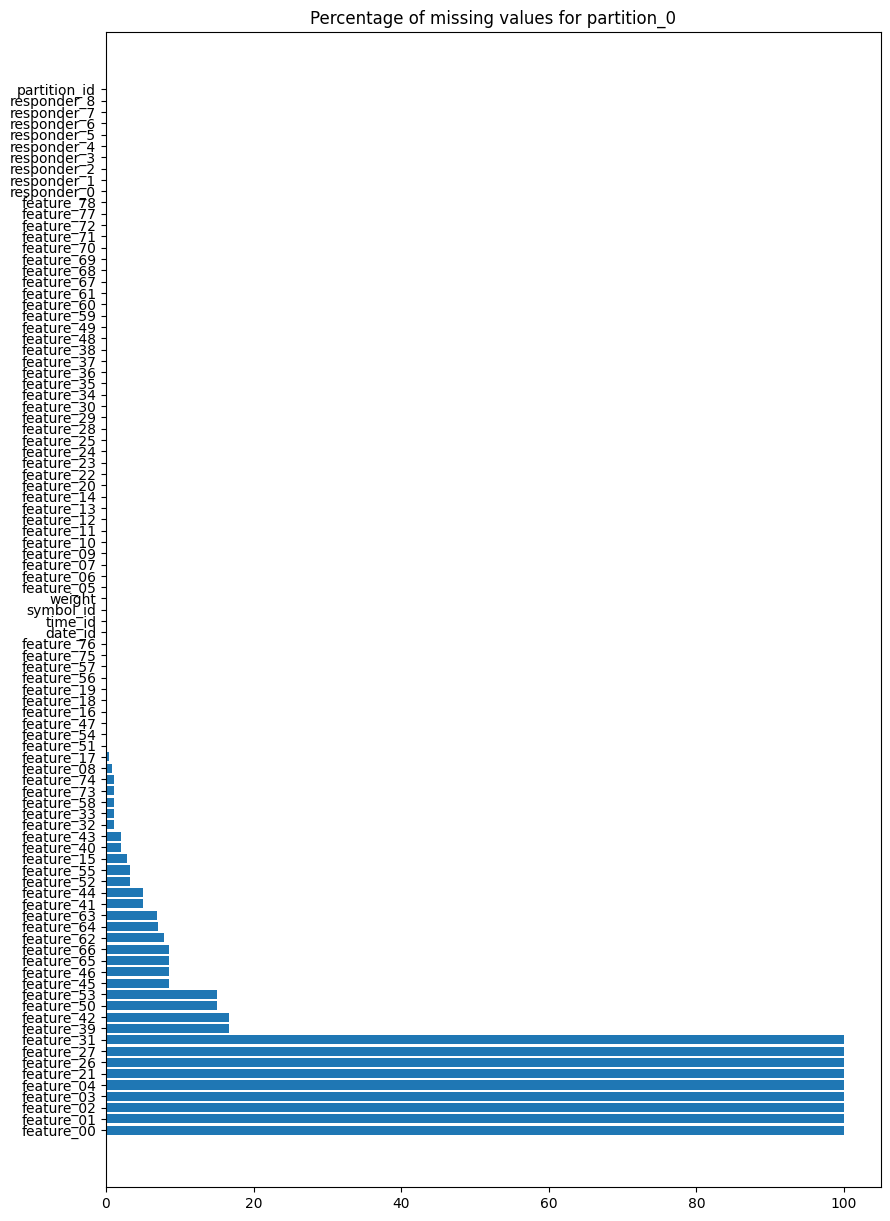

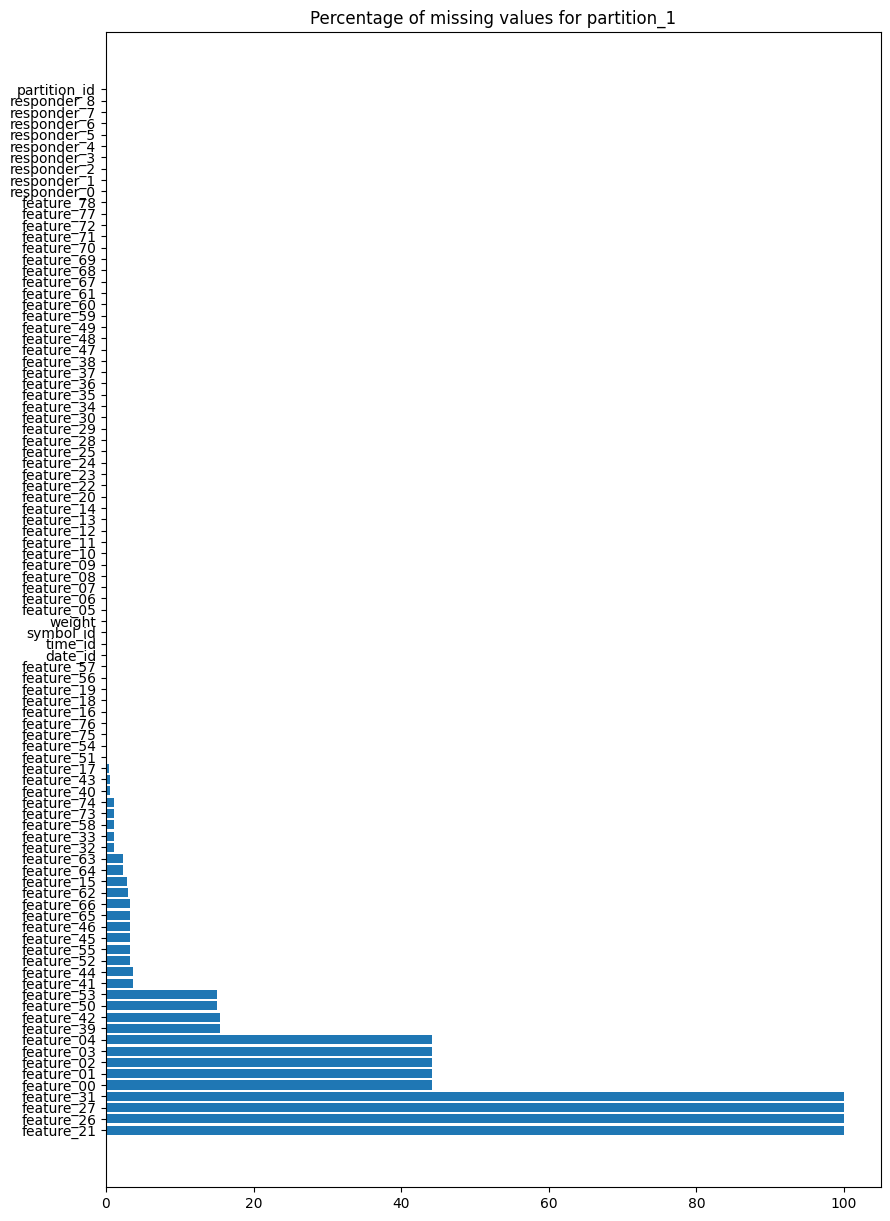

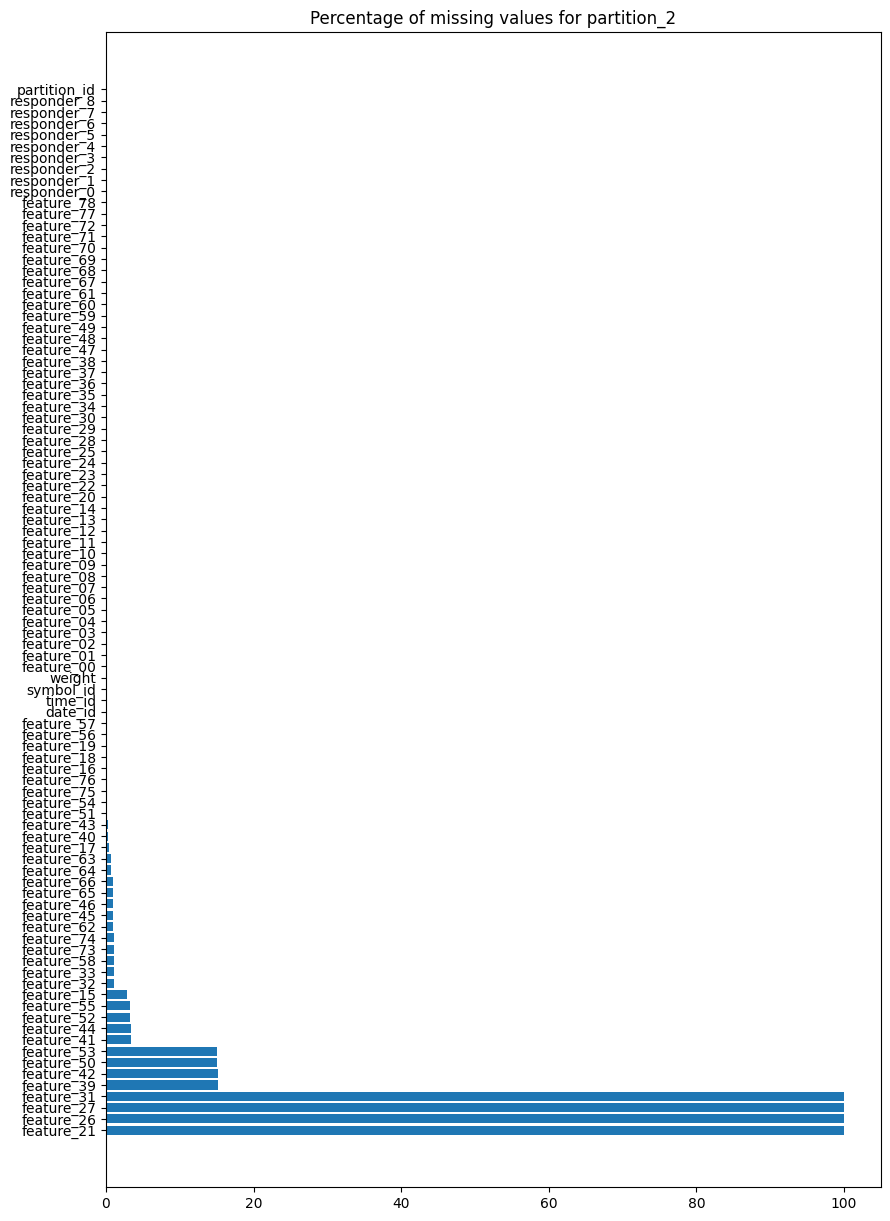

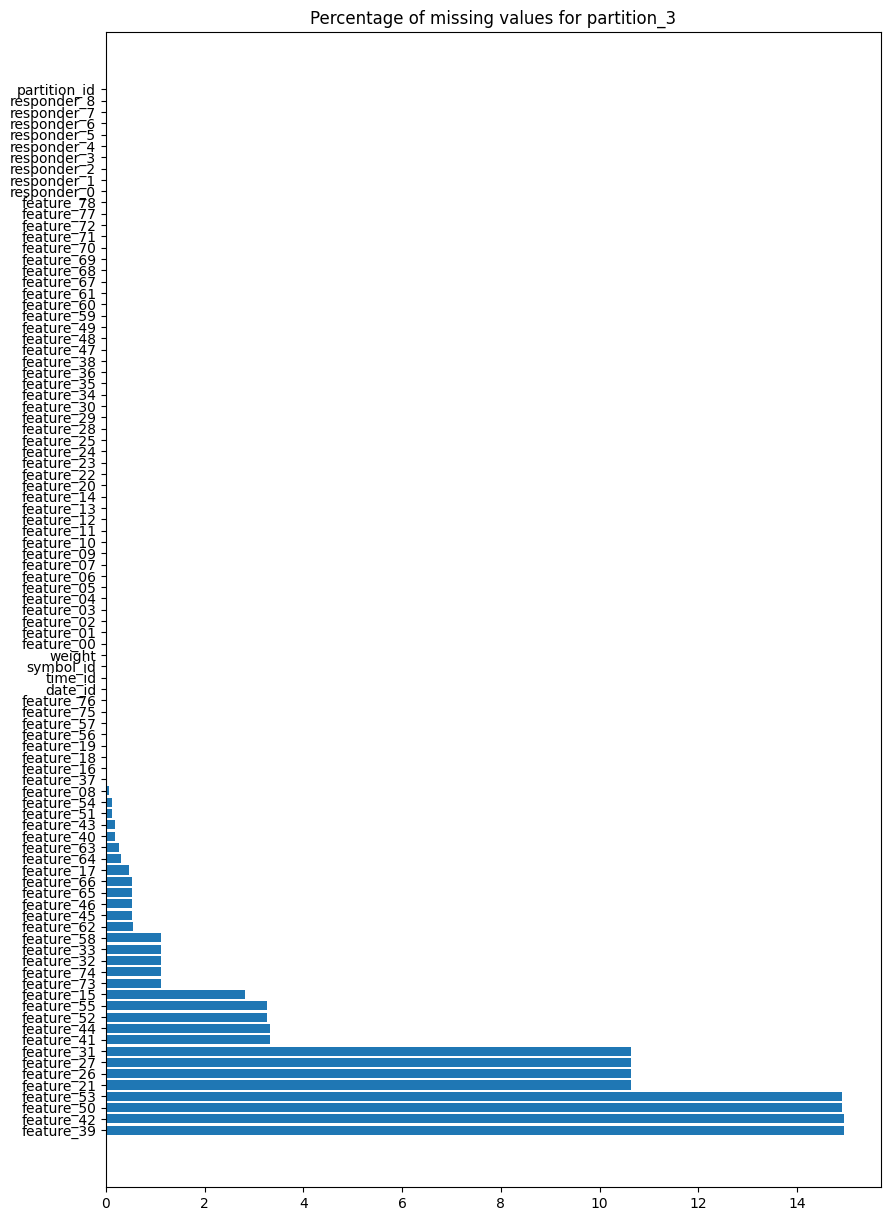

In [6]:
for i in range(4):
  df = train.filter(pl.col("partition_id") == i).collect()
  df_null = df.null_count()
  df_null = (
    df_null.transpose(
    include_header=True,
    header_name='feature',
    column_names=['null_count']
    )
    .sort('null_count', descending=True)
    )
  df_null = df_null.with_columns(
    pl.col('null_count') / len(df) * 100
    )

  plt.figure(figsize=(10, 15))
  plt.barh(df_null['feature'].to_list(), df_null['null_count'].to_list());
  plt.title(f"Percentage of missing values for partition_{i}")


- 6.5 hours for full day trading (9:30 AM to 4:00 PM)
- the assumption here is data is taken for the whole open trading hours for the day which may not be true, for example the data maybe taken only for the last 15 minutes of trading hours
- Observation: later data partitions have higher sampling rates
- Each partition has 170 date_ids except for the last partition which has 169 date_ids


### Number of data points(millions) for each partition
1.94\
2.8\
3.04\
4.02\
5.02\
5.35\
6.2\
6.34\
6.14\
6.27


In [7]:
# df = train.filter(pl.col("partition_id") == 9).collect()
# df_count = df.group_by('date_id').len().sort('len')
# sns.histplot(df_count, x='len')
# df_count.describe()

In [8]:
for i in range(10):
  df = train.filter(pl.col("partition_id") == i)
  num_rows = df.select(pl.len()).collect().item() / 1e6
  print(np.round(num_rows, 2))


1.94
2.8
3.04
4.02
5.02
5.35
6.2
6.34
6.14
6.27


# Time_id
- partition 0 - 2 (date_id 0 - 509) time_id runs from 0 to 848
- partition 3 - 9 (date_id 510 - 1698) time_id runs from 0 - 967

16 minutes of trading hours for each trading day?

In [9]:
df = train.filter(pl.col("partition_id") == 9).select(
    pl.col(['date_id', 'time_id'])
    ).collect()
df.filter(pl.col('date_id') == 1530)

date_id,time_id
i16,i16
1530,0
1530,0
1530,0
1530,0
1530,0
…,…
1530,967
1530,967
1530,967


## Responders

In [10]:
df = train.filter(pl.col("partition_id") == 1).select(
    pl.col(['date_id', 'time_id'] + [f"responder_{i}" for i in range(9)])
).collect()
df


date_id,time_id,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8
i16,i16,f32,f32,f32,f32,f32,f32,f32,f32,f32
170,0,-0.293646,-0.061842,-0.305413,-0.419151,-0.111796,-0.535104,-0.044332,-0.039061,-0.744789
170,0,-0.075267,-0.35936,-1.270054,-0.018332,-0.040286,-1.417509,0.08584,0.487232,-0.124533
170,0,-5.0,-5.0,0.194658,-5.0,-5.0,-5.0,1.5834,0.018712,-1.055035
170,0,3.336086,2.051951,2.400644,0.96273,-0.939277,1.84587,-2.372452,-1.663179,-4.585349
170,0,-0.707027,-0.344866,-1.248052,-0.129645,-3.145927,-0.452708,0.300044,0.489202,0.242737
…,…,…,…,…,…,…,…,…,…,…
339,848,0.163901,0.134067,1.124346,0.484879,0.255225,0.479602,0.00854,0.027126,0.000452
339,848,0.637513,-0.01148,1.779785,0.757132,0.274228,0.741818,1.014812,0.573904,2.35997
339,848,-3.343947,-1.012429,-2.968987,-1.112956,-0.598563,-1.537665,-0.25963,-0.105986,-0.480081


<Axes: xlabel='responder_6', ylabel='Count'>

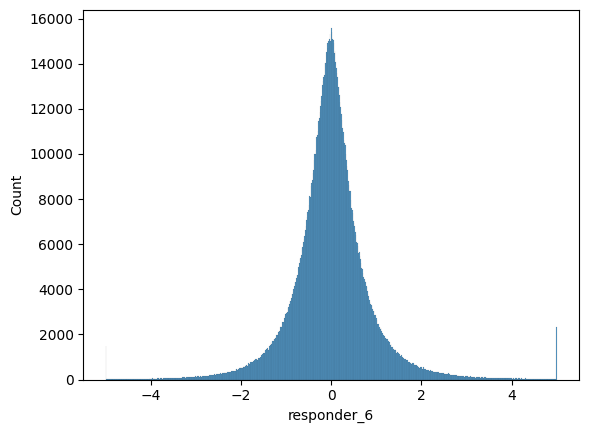

In [11]:
sns.histplot(df.sample(fraction = 0.5), x='responder_6')

## Features
- tag_0
- tag_1 feature 9, 10, 11 - counts , feature_10 seems categorical
- tag_3 28 features



In [12]:
df_feats = pl.read_csv("/content/drive/MyDrive/Colab Notebooks/Jane_Street/data/features.csv")
display(df_feats.head())

feat_cols = df_feats.filter(pl.col('tag_4')==True)['feature'].to_list()
print()
print(len(feat_cols))
feat_cols

feature,tag_0,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9,tag_10,tag_11,tag_12,tag_13,tag_14,tag_15,tag_16
str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
"""feature_00""",false,false,true,false,false,false,false,false,false,false,false,false,false,false,true,false,true
"""feature_01""",false,false,true,false,false,false,false,false,false,false,false,false,false,true,true,false,true
"""feature_02""",false,false,true,false,false,false,false,false,false,false,false,false,true,false,false,false,true
"""feature_03""",false,false,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true
"""feature_04""",false,false,true,false,false,false,false,false,false,false,false,false,true,true,false,false,true



10


['feature_18',
 'feature_39',
 'feature_40',
 'feature_41',
 'feature_45',
 'feature_50',
 'feature_51',
 'feature_52',
 'feature_56',
 'feature_65']

In [13]:
df = train.filter(pl.col("partition_id") >8).select(
    pl.col(feat_cols)
).collect()

df.head()

feature_18,feature_39,feature_40,feature_41,feature_45,feature_50,feature_51,feature_52,feature_56,feature_65
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
-1.238222,null,0.081268,null,-1.967165,null,0.680807,null,-1.2279,-1.333965
-1.46613,null,0.002134,null,-1.304763,null,-0.00268,null,-2.354893,-1.797363
-1.301579,null,0.486033,null,-1.019831,null,0.793936,null,-2.190607,-1.598371
-1.917427,null,1.388513,null,-0.693391,null,2.07314,null,-0.760486,-2.062314
-1.55811,null,0.743995,null,-1.331183,null,0.549144,null,-1.490257,-1.780053


In [14]:
df.min()

feature_18,feature_39,feature_40,feature_41,feature_45,feature_50,feature_51,feature_52,feature_56,feature_65
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
-4.310348,-4.037675,-4.144327,-4.142577,-3.700696,-3.699676,-3.279817,-3.545756,-4.084827,-5.002984


In [15]:
df.max()

feature_18,feature_39,feature_40,feature_41,feature_45,feature_50,feature_51,feature_52,feature_56,feature_65
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
5.635913,4.019478,3.83686,3.918105,3.728817,4.003451,3.976008,4.178951,3.895288,5.786398


In [16]:
df.shape[0] / 1e6

6.274576

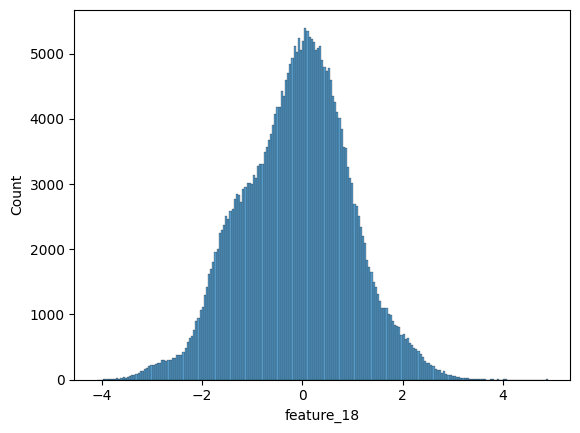

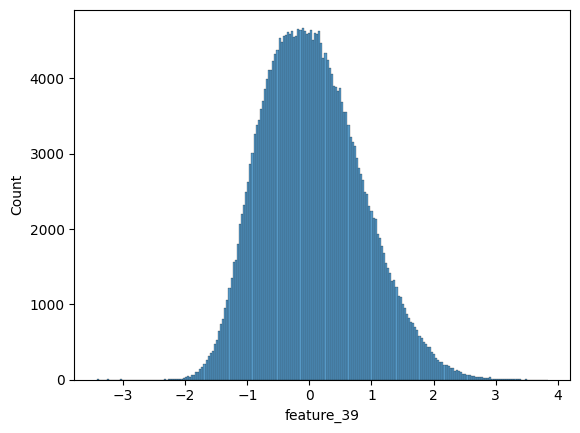

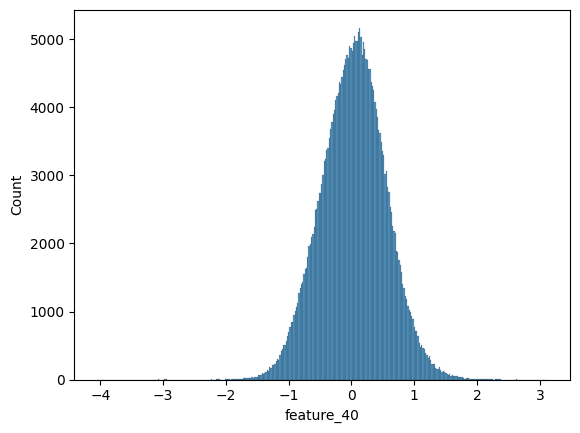

In [17]:
s = 0
for i in range(s, s+3):
  plt.figure()
  sns.histplot(df.sample(fraction=0.05), x=feat_cols[i])

## Responders

In [18]:
df_resp = pl.read_csv("/content/drive/MyDrive/Colab Notebooks/Jane_Street/data/responders.csv")
#display(df_resp)
resp_cols = df_resp.filter(pl.col('tag_2')==True)['responder'].to_list()
resp_cols

['responder_0', 'responder_3', 'responder_6']

In [19]:
df = train.filter(pl.col("partition_id") == 9).select(
    pl.col(resp_cols)
    )
#df.shape

In [20]:
df.select('responder_6').min().collect()

responder_6
f32
-5.0


In [21]:
df.select('responder_6').max().collect()

responder_6
f32
5.0


In [22]:
df = df.with_columns(
    (pl.col('responder_6'))
).collect()

In [23]:
df['responder_6'].min()

-5.0

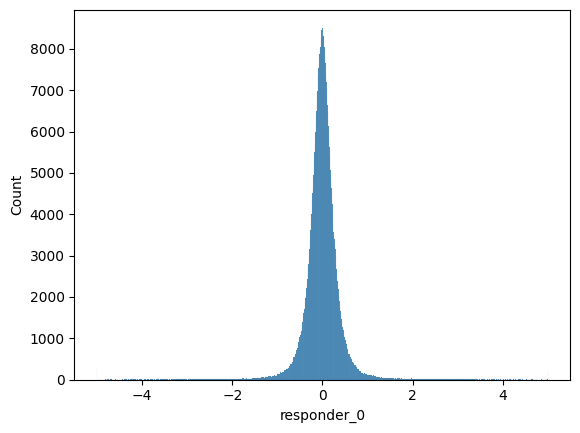

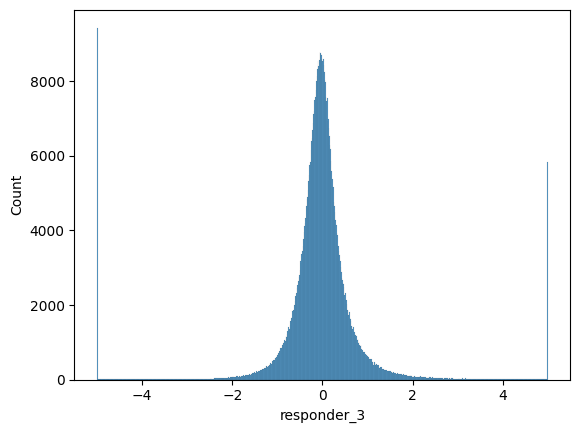

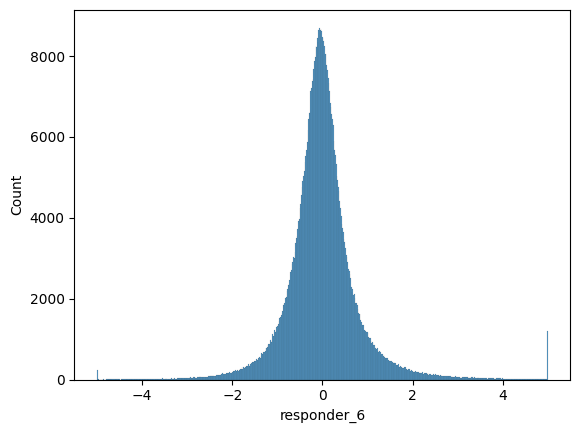

In [24]:
for i in range(3):
  plt.figure()
  sns.histplot(df.sample(fraction=0.1), x=resp_cols[i])

## Lags

In [25]:
# df_lags = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/Jane_Street/data/lags.parquet/date_id=0/part-0.parquet")

# Test

In [26]:
# test = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/Jane_Street/data/test.parquet/date_id=0/part-0.parquet")
# test = pl.from_pandas(test)